In [16]:
import pandas as pd
import numpy as np
import scanpy as sc
import squidpy as sq
import torch
import scipy as sp

import sys
sys.path.append("../")
import steamboat as sf
import steamboat.tools

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['mathtext.fontset'] = 'dejavuserif'
matplotlib.rcParams['font.family'] = 'arial'
matplotlib.rcParams["legend.handletextpad"] = 0.
matplotlib.rcParams["legend.labelspacing"] = .3
pltkw = dict(bbox_inches='tight', transparent=True)
from joblib import Parallel, delayed
import seaborn as sns

In [ ]:
adata = sc.read_h5ad("../data/Ex5_slide_tags_human_tonsil/HumanTonsil_2000.h5ad")

In [18]:
adata.obs['global'] = 0
adatas = sf.prep_adatas([adata], norm=False, log1p=False, n_neighs=8)
dataset = sf.make_dataset(adatas, sparse_graph=True, regional_obs=['global'])

  0%|          | 0/1 [00:00<?, ?it/s]

Using None to mask variables. Explicitly specify `mask_var=False` to use all genes.
Using ['global'] as regional annotations.


  0%|          | 0/1 [00:00<?, ?it/s]

In [19]:
device = 'cuda'
sf.set_random_seed(0)
model = sf.Steamboat(adata.var_names.tolist(), n_heads=60, n_scales=3)
model = model.to(device)

In [20]:
# model.fit(dataset.to(device), entry_masking_rate=0.1, feature_masking_rate=0.1,
#             max_epoch=10000, 
#             loss_fun=torch.nn.MSELoss(reduction='sum'),
#             opt=torch.optim.Adam, opt_args=dict(lr=0.1), stop_eps=2e-5, report_per=1000, stop_tol=250, device=device)

# torch.save(model.state_dict(), 'saved_models/tonsil.pth')

# [2025-10-02 12:25:00,171::train::INFO] Epoch 1: train_loss 393.33020
# [2025-10-02 12:25:06,773::train::INFO] Epoch 1001: train_loss 206.91405
# [2025-10-02 12:25:13,339::train::INFO] Epoch 2001: train_loss 203.47221
# [2025-10-02 12:25:19,166::train::INFO] Epoch 2886: train_loss 203.11626
# [2025-10-02 12:25:19,167::train::INFO] Stopping criterion met.

In [ ]:
model.load_state_dict(torch.load('../data/saved_models/tonsil.pth'))

<All keys matched successfully>

In [22]:
sf.tools.calc_obs(adatas, dataset, model, get_recon=True)
sf.tools.gather_obs(adata, adatas)

  0%|          | 0/1 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 5778 × 2000
    obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'cluster', 'global'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cluster_colors', 'hvg', 'neighbors', 'pca', 'umap', 'spatial_neighbors', 'global_k_0'
    obsm: 'X_pca', 'X_umap', 'spatial', 'X_recon', 'q', 'local_k', 'global_k_0', 'attn', 'ego_attn', 'local_attn', 'global_attn_0', 'global_attn'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances', 'local_attn_0', 'local_attn_1', 'local_attn_2', 'local_attn_3', 'local_attn_4', 'local_attn_5', 'local_attn_6', 'local_attn_7', 'local_attn_8', 'local_attn_9', 'local_attn_10', 'local_attn_11', 'local_attn_12', 'local_attn_13', 'local_attn_14', 'local_attn_15', 'local_attn_16', '

In [23]:
var = sf.tools.calc_var(model)
sf.tools.calc_obs(adatas, dataset, model, get_recon=True)

  0%|          | 0/1 [00:00<?, ?it/s]

In [24]:
adata.obs

,biosample_id,donor_id,species,species__ontology_label,disease,disease__ontology_label,organ,organ__ontology_label,library_preparation_protocol,library_preparation_protocol__ontology_label,sex,cluster,global
AAACCCAAGCGCCTTG-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,T_CD4,0
AAACCCAAGTGGACGT-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,plasma,0
AAACCCACAGAAGTGC-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,B_germinal_center,0
AAACCCAGTCATTGCA-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,B_naive,0
AAACCCATCATCGCAA-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,B_memory,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGCAGGGACTA-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,B_germinal_center,0
TTTGTTGCATTGTAGC-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,plasma,0
TTTGTTGGTACCACGC-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,B_germinal_center,0
TTTGTTGGTCTGTCCT-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,T_CD4,0


In [25]:
adata.obs = pd.read_csv('saved_results/tonsil_spatial_domain_all_methods.csv', index_col=0)

In [26]:
adata.obs['region'] = adata.obs['steamboat_spatial_domain_2_labeled']
regions = adata.obs['region'].unique().tolist()

In [27]:
adata.obs.head().style

,biosample_id,donor_id,species,species__ontology_label,disease,disease__ontology_label,organ,organ__ontology_label,library_preparation_protocol,library_preparation_protocol__ontology_label,sex,cluster,global,std_attn_leiden,steamboat_spatial_domain_2,steamboat_spatial_domain_2_labeled,banksy,banksy_labeled,SEDR,SEDR_labeled,stagate,stagate_labeled,region
AAACCCAAGCGCCTTG-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,T_CD4,0,2,1,TZ,0,TZ/MZ,1,GC/TZ,0,TZ,TZ
AAACCCAAGTGGACGT-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,plasma,0,4,0,GC,1,GC,1,GC/TZ,2,GC,GC
AAACCCACAGAAGTGC-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,B_germinal_center,0,1,0,GC,1,GC,1,GC/TZ,2,GC,GC
AAACCCAGTCATTGCA-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,B_naive,0,0,2,MZ,0,TZ/MZ,1,GC/TZ,1,MZ,MZ
AAACCCATCATCGCAA-1,tonsil1,human_tonsil1,NCBITaxon_9606,Homo sapiens,PATO_0000461,normal,UBERON:0002373,palatine tonsil,EFO_0009922,10x 3' v3,unknown,B_memory,0,0,1,TZ,0,TZ/MZ,1,GC/TZ,0,TZ,TZ


In [55]:
adata.obs['major_cluster'] = 'other'
mapping = {
    'B_germinal_center': 'B_cell',
    'B_memory': 'B_cell',
    'B_naive': 'B_cell',
    'T_CD4': 'T_cell',
    'T_CD8': 'T_cell',
    'T_double_neg': 'T_cell',
    'T_follicular_helper': 'T_cell'
}
adata.obs['major_cluster'] = adata.obs['cluster'].apply(lambda x: mapping.get(x, 'other'))

In [28]:
crosstab = pd.crosstab(adata.obs['cluster'], adata.obs['region'])
crosstab = crosstab.div(crosstab.sum(axis=1), axis=0)
crosstab

region,GC,MZ,TZ
cluster,,,
B_germinal_center,0.925325,0.035714,0.038961
B_memory,0.034884,0.705426,0.259690
B_naive,0.024367,0.836926,0.138707
FDC,0.474510,0.254902,0.270588
NK,0.076471,0.164706,0.758824
T_CD4,0.028241,0.077022,0.894737
T_CD8,0.037815,0.218487,0.743697
T_double_neg,0.000000,0.217391,0.782609
T_follicular_helper,0.789116,0.071429,0.139456


In [29]:
clusters = crosstab.index[(crosstab > 0.1).sum(axis=1) > 1].tolist()

In [30]:
adata.obs['cluster'].value_counts()

cluster
B_germinal_center      1848
B_naive                1067
T_CD4                   779
B_memory                516
T_follicular_helper     294
plasma                  262
FDC                     255
T_CD8                   238
NK                      170
mDC                     137
myeloid                 102
pDC                      64
T_double_neg             46
Name: count, dtype: int64

In [61]:
# cluster_count_series = adata.obs['cluster'].value_counts()
# clusters = cluster_count_series[cluster_count_series > 100].index.tolist()
clusters = ['plasma', 'FDC', 'myeloid']

dist_list = []
label = []
group = []

for i in clusters:
    sub_adata = adata[adata.obs['cluster'] == i]
    for region in regions:
        sub_sub_adata = sub_adata[sub_adata.obs['region'] == region]
        if len(sub_sub_adata) < 1:
            continue
        inner_dist = sp.spatial.distance.pdist(sub_sub_adata.obsm['attn'], metric='euclidean')
        dist_list.extend(inner_dist)
        label.extend([i] * len(inner_dist))
        group.extend(['same-region'] * len(inner_dist))

    for region1 in regions:
        for region2 in regions:
            if region1 == region2:
                continue
            sub_sub_adata1 = sub_adata[sub_adata.obs['region'] == region1]
            sub_sub_adata2 = sub_adata[sub_adata.obs['region'] == region2]
            if len(sub_sub_adata1) < 1 or len(sub_sub_adata2) < 1:
                continue
            inter_dist = sp.spatial.distance.cdist(sub_sub_adata1.obsm['attn'], sub_sub_adata2.obsm['attn'], metric='euclidean').flatten()
            dist_list.extend(inter_dist)
            label.extend([i] * len(inter_dist))
            group.extend(['cross-region'] * len(inter_dist))

In [62]:
all_df = pd.DataFrame({'Label': label, 'Distance': dist_list, 'Group': group})
np.random.seed(0)
plot_df = all_df.groupby(['Label', 'Group']).sample(n=2000, replace=True).sort_values('Label')

In [63]:
test_results = {'label': [], 'f_statistic': [], 'p_value': []}
for i in all_df['Label'].unique():
    sub_df = all_df[all_df['Label'] == i]
    sub_df_same = sub_df[sub_df['Group'] == 'same-region']
    sub_df_diff = sub_df[sub_df['Group'] == 'cross-region']
    result = sp.stats.mannwhitneyu(sub_df_same['Distance'], sub_df_diff['Distance'], alternative='two-sided')
    test_f = result.statistic / (len(sub_df_same) * len(sub_df_diff))
    test_p = result.pvalue
    test_results['label'].append(i)
    test_results['f_statistic'].append(test_f)
    test_results['p_value'].append(test_p)
    print(f"{i}: f = {test_f}, p-value = {test_p}")

plasma: f = 0.362776089869309, p-value = 0.0
FDC: f = 0.3263085116972524, p-value = 0.0
myeloid: f = 0.3244482469205854, p-value = 9.138690918837504e-118


C:\Users\lshh\AppData\Local\Temp\ipykernel_53728\1232275539.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor', fontsize=8)
C:\Users\lshh\AppData\Local\Temp\ipykernel_53728\1232275539.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=8)


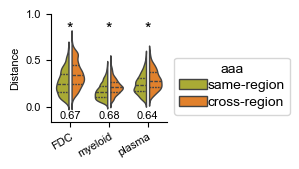

In [ ]:
fig, ax = plt.subplots(figsize=(1.5, 1.4))
sns.violinplot(
        data=plot_df,
        x="Label",
        y="Distance",
        hue=plot_df["Group"].tolist(),                    # when you have hue
        split=True,
        hue_order=["same-region", "cross-region"], # set hue_order with cat instead of bool
        inner='quart',
        density_norm='width',
        gap=.2,
        ax=ax,
        palette=['C8', 'C1'],
        linewidth=1.,
    )
plt.xticks(rotation=30, ha='right', rotation_mode='anchor', fontsize=8)
plt.ylim(-0.16, 1.)

ax.set_xlabel('')
ax.set_ylabel('Distance', fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor', fontsize=8)
ax.set_yticklabels(ax.get_yticks(), fontsize=8)

ax.legend(title='aaa', fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))

test_df = pd.DataFrame(test_results).sort_values('label').reset_index(drop=True)
for idx, row in test_df.iterrows():
    label = row['label']
    f_statistic = 1 - row['f_statistic']
    p_value = row['p_value']
    annotation = ''
    if p_value < 1e-5:
        annotation = '*'
    annotation2 = '{:.2f}'.format(f_statistic)
    ax.text(idx, 0.75, annotation, ha='center', va='bottom', fontsize=12)
    ax.text(idx, -0.15, annotation2, ha='center', va='bottom', fontsize=8)


for pos in ['right', 'top']:
    ax.spines[pos].set_visible(False)

sns.move_legend(ax, "lower left", bbox_to_anchor=(1, 0))

In [68]:
region2color = {'GC': '#144B99', 'TZ': '#CCAA7A', 'MZ': '#7CBDCB'}

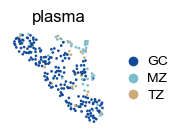

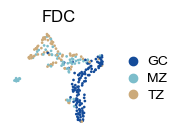

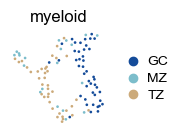

In [ ]:
for i in clusters:
    sub_adata = adata[adata.obs['cluster'] == i]
    sub_adata = sub_adata[sub_adata.obs['region'].isin(regions)]
    sc.pp.neighbors(sub_adata, n_neighbors=10, use_rep='attn', key_added='attn_neighbors', metric='cosine')
    sc.tl.umap(sub_adata, neighbors_key='attn_neighbors')

    fig, ax = plt.subplots(figsize=(1.25, 1.25))
    sc.pl.umap(sub_adata, color='region', palette=region2color, ax=ax, title=i, frameon=False, size=15, show=False)